# Phase 1: E-commerce Database Setup & Analysis
## Data Analysis Internship - Machine Learning Track

**Goal:** Build and analyse an e-commerce database using SQL and Python

**Tools:** SQLite, Pandas, Matplotlib, Seaborn

---

## Table of Contents
1. [Step 1: Database Setup](#Step-1)
2. [Step 2: Data Quality Analysis](#Step-2)
3. [Step 3: SQL Business Analysis](#Step-3)
4. [Step 4: Documentation & Report](#Step-4)

---

<a id='Step-1'></a>
# Step 1: SQLite Database Setup

## Objectives:
- Create SQLite database
- Design normalised schema (4 tables)
- Load and clean CSV data
- Verify data integrity

## Deliverables:
-  `ecommerce.db` file
-  Data cleaning script
-  Database verification report

## Setup: Install Required Packages

In [40]:
!python -m pip install pandas matplotlib
!python -m pip install seaborn


In [41]:
"""
Step 1: SQLite Database Setup for E-commerce Data
============================================================

This script will:
1. Create a SQLite database
2. Design proper table schema
3. Load CSV data into the database
4. Perform initial data quality checks

Requirements:
- Python 3.x
- pandas library: pip install pandas
- SQLite (comes built-in with Python)

Author: Muhammad Hashim Abbas
"""

import os
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime

# ============================================================
# STEP 1: DATABASE CONNECTION AND SETUP
# ============================================================

def create_database_connection(db_name='ecommerce.db'):
    """
    Create or connect to SQLite database
    
    Args:
        db_name: Name of the database file
    
    Returns:
        Connection object
    """
    print(f" Creating/connecting to database: {db_name}")
    conn = sqlite3.connect(db_name)
    print(" Database connection established!")
    return conn


# ============================================================
# STEP 2: CREATE DATABASE SCHEMA
# ============================================================

def create_tables(conn):
    """
    Create normalised database schema for e-commerce data
    
    We'll create 4 main tables:
    1. customers - unique customer information
    2. products - unique product information  
    3. invoices - invoice/order header
    4. invoice_items - individual items in each invoice
    """
    cursor = conn.cursor()
    
    print("\n Creating database tables...")
    
    # Table 1: Customers
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS customers (
            customer_id INTEGER PRIMARY KEY,
            country TEXT NOT NULL,
            first_purchase_date TEXT,
            last_purchase_date TEXT,
            total_orders INTEGER DEFAULT 0,
            created_at TEXT DEFAULT CURRENT_TIMESTAMP
        )
    """)
    print(" Created 'customers' table")
    
    # Table 2: Products
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS products (
            stock_code TEXT PRIMARY KEY,
            description TEXT,
            avg_unit_price REAL,
            total_quantity_sold INTEGER DEFAULT 0,
            created_at TEXT DEFAULT CURRENT_TIMESTAMP
        )
    """)
    print(" Created 'products' table")
    
    # Table 3: Invoices (Order Header)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS invoices (
            invoice_no TEXT PRIMARY KEY,
            customer_id INTEGER,
            invoice_date TEXT NOT NULL,
            country TEXT,
            total_amount REAL DEFAULT 0,
            total_items INTEGER DEFAULT 0,
            created_at TEXT DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
        )
    """)
    print(" Created 'invoices' table")
    
    # Table 4: Invoice Items (Order Lines)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS invoice_items (
            item_id INTEGER PRIMARY KEY AUTOINCREMENT,
            invoice_no TEXT NOT NULL,
            stock_code TEXT NOT NULL,
            description TEXT,
            quantity INTEGER NOT NULL,
            unit_price REAL NOT NULL,
            line_total REAL,
            created_at TEXT DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (invoice_no) REFERENCES invoices(invoice_no),
            FOREIGN KEY (stock_code) REFERENCES products(stock_code)
        )
    """)
    print(" Created 'invoice_items' table")
    
    conn.commit()
    print("\n All tables created successfully!\n")


# ============================================================
# STEP 3: LOAD AND CLEAN DATA
# ============================================================

def load_csv_data(file_path):
    """
    Load CSV data and perform initial cleaning
    
    Args:
        file_path: Path to your CSV file
    
    Returns:
        Cleaned DataFrame
    """
    print(f" Loading data from: {file_path}")
    
    # Load the data
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
    
    print(f" Loaded {len(df):,} rows")
    print(f" Columns: {list(df.columns)}")
    
    # Initial data info
    print("\n Initial Data Quality Check:")
    print(f"   - Total rows: {len(df):,}")
    print(f"   - Missing CustomerID: {df['CustomerID'].isna().sum():,}")
    print(f"   - Missing Description: {df['Description'].isna().sum():,}")
    print(f"   - Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
    
    return df


def clean_data(df):
    """
    Clean the dataset before loading into database (RFM / CLV ready)
    
    Arguments:
        df: Raw DataFrame
    
    Returns:
        Cleaned DataFrame
    """
    print("\n Cleaning data...")
    
    original_rows = len(df)
    
    # 1. Remove rows with missing CustomerID
    df = df.dropna(subset=['CustomerID'])
    print(f"   ✓ Removed {original_rows - len(df):,} rows with missing CustomerID")
    
    # 2. Convert CustomerID to integer
    df['CustomerID'] = df['CustomerID'].astype(int)
    
    # 3. Clean Description
    df['Description'] = df['Description'].fillna('Unknown Product')
    
    # 4. Parse dates properly
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    
    # 5. Calculate line total (IMPORTANT for RFM/CLV)
    df['LineTotal'] = df['Quantity'] * df['UnitPrice']
    
    # 6. Remove zero-value transactions only (keep returns/refunds)
    before = len(df)
    df = df[df['LineTotal'] != 0]
    print(f"   ✓ Removed {before - len(df):,} zero-value transactions")
    
    # 7. Remove 'Unspecified' country
    before = len(df)
    df = df[df['Country'] != 'Unspecified']
    print(f"   ✓ Removed {before - len(df):,} rows with Country = 'Unspecified'")
    
    print(f"\n Cleaned data: {len(df):,} rows remaining")
    
    return df



# ============================================================
# STEP 4: INSERT DATA INTO DATABASE
# ============================================================

def populate_customers_table(df, conn):
    """
    Populate the customers table with unique customer data
    """
    print("\n Populating customers table...")
    
    # Aggregate customer-level data
    customer_data = df.groupby('CustomerID').agg({
        'Country': 'first',  # Take first country (customers usually from one country)
        'InvoiceDate': ['min', 'max'],  # First and last purchase
        'InvoiceNo': 'nunique'  # Total unique orders
    }).reset_index()
    
    # Flatten column names
    customer_data.columns = ['customer_id', 'country', 'first_purchase_date', 
                             'last_purchase_date', 'total_orders']
    
    # Convert dates to string format
    customer_data['first_purchase_date'] = customer_data['first_purchase_date'].astype(str)
    customer_data['last_purchase_date'] = customer_data['last_purchase_date'].astype(str)
    
    # Insert into database
    customer_data.to_sql('customers', conn, if_exists='replace', index=False)
    
    print(f" Inserted {len(customer_data):,} unique customers")
    return customer_data


def populate_products_table(df, conn):
    """
    Populate the products table with unique product data
    """
    print("\n Populating products table...")
    
    # Aggregate product-level data
    product_data = df.groupby('StockCode').agg({
        'Description': 'first',  # Take first description
        'UnitPrice': 'mean',  # Average price
        'Quantity': 'sum'  # Total quantity sold
    }).reset_index()
    
    product_data.columns = ['stock_code', 'description', 'avg_unit_price', 'total_quantity_sold']
    
    # Insert into database
    product_data.to_sql('products', conn, if_exists='replace', index=False)
    
    print(f" Inserted {len(product_data):,} unique products")
    return product_data


def populate_invoices_table(df, conn):
    """
    Populate the invoices table with order header data
    """
    print("\n Populating invoices table...")
    
    # Aggregate invoice-level data
    invoice_data = df.groupby('InvoiceNo').agg({
        'CustomerID': 'first',
        'InvoiceDate': 'first',
        'Country': 'first',
        'LineTotal': 'sum',  # Total invoice amount
        'Quantity': 'sum'  # Total items in invoice
    }).reset_index()
    
    invoice_data.columns = ['invoice_no', 'customer_id', 'invoice_date', 
                           'country', 'total_amount', 'total_items']
    
    # Convert date to string
    invoice_data['invoice_date'] = invoice_data['invoice_date'].astype(str)
    
    # Insert into database
    invoice_data.to_sql('invoices', conn, if_exists='replace', index=False)
    
    print(f" Inserted {len(invoice_data):,} unique invoices")
    return invoice_data


def populate_invoice_items_table(df, conn):
    """
    Populate the invoice_items table with line-item data
    """
    print("\n Populating invoice_items table...")
    
    # Select relevant columns
    items_data = df[['InvoiceNo', 'StockCode', 'Description', 
                     'Quantity', 'UnitPrice', 'LineTotal']].copy()
    
    items_data.columns = ['invoice_no', 'stock_code', 'description', 
                         'quantity', 'unit_price', 'line_total']
    
    # Insert into database (this might take a moment for large datasets)
    items_data.to_sql('invoice_items', conn, if_exists='replace', index=False)
    
    print(f" Inserted {len(items_data):,} invoice line items")
    return items_data


# ============================================================
# STEP 5: DATA QUALITY VERIFICATION
# ============================================================

def verify_data_quality(conn):
    """
    Run verification queries to ensure data was loaded correctly
    """
    print("\n" + "="*60)
    print(" DATA QUALITY VERIFICATION")
    print("="*60)
    
    cursor = conn.cursor()
    
    # Check 1: Row counts
    print("\n1️⃣ Table Row Counts:")
    for table in ['customers', 'products', 'invoices', 'invoice_items']:
        cursor.execute(f"SELECT COUNT(*) FROM {table}")
        count = cursor.fetchone()[0]
        print(f"   {table}: {count:,} rows")
    
    # Check 2: Sample data from each table
    print("\n2️⃣ Sample Data Preview:")
    print("\n   Customers (first 3):")
    cursor.execute("SELECT * FROM customers LIMIT 3")
    for row in cursor.fetchall():
        print(f"      {row}")
    
    print("\n   Products (first 3):")
    cursor.execute("SELECT * FROM products LIMIT 3")
    for row in cursor.fetchall():
        print(f"      {row}")
    
    # Check 3: Basic statistics
    print("\n3️⃣ Basic Statistics:")
    
    cursor.execute("SELECT COUNT(DISTINCT country) FROM customers")
    countries = cursor.fetchone()[0]
    print(f"   Unique countries: {countries}")
    
    cursor.execute("SELECT SUM(total_amount) FROM invoices")
    total_revenue = cursor.fetchone()[0]
    print(f"   Total revenue: ${total_revenue:,.2f}")
    
    cursor.execute("SELECT AVG(total_amount) FROM invoices")
    avg_order = cursor.fetchone()[0]
    print(f"   Average order value: ${avg_order:,.2f}")
    
    print("\n Database verification complete!")


# ============================================================
# MAIN EXECUTION
# ============================================================

def main():
    
    print("Current working directory:", os.getcwd())
    
    """
    Main execution function - runs all setup steps
    """
    print("="*60)
    print(" Step 1: E-COMMERCE DATABASE SETUP")
    print("="*60)
    
    # Configuration
    #CSV_FILE = 'customer_segmentation_data-reduced2.csv'
    CSV_FILE = 'customer_segmentation_data.csv'
    DB_NAME = 'ecommerce.db'
    
    try:
        # Step 1: Create database connection
        conn = create_database_connection(DB_NAME)
        
        # Step 2: Create tables
        create_tables(conn)
        
        # Step 3: Load and clean data
        df = load_csv_data(CSV_FILE)
        df_clean = clean_data(df)
        
        # Step 4: Populate all tables
        populate_customers_table(df_clean, conn)
        populate_products_table(df_clean, conn)
        populate_invoices_table(df_clean, conn)
        populate_invoice_items_table(df_clean, conn)
        
        # Step 5: Verify data quality
        verify_data_quality(conn)
        
        # Close connection
        conn.close()
        
        print("\n" + "="*60)
        print(" SUCCESS! The database is ready!")
        print("="*60)
        print(f"\n Database file created: {DB_NAME}")
        print(" THis database can now be using SQL!")
        print("\n Next Steps:")
        print("   1. Open the database file in a SQLite browser")
        print("   2. Or use Python to run SQL queries")
        print("   3. Start data analysis!")
        
    except Exception as e:
        print(f"\n Error occurred: {e}")
        raise

main()

Current working directory: c:\Users\ma053309\Desktop\Internship\final_docs
 Step 1: E-COMMERCE DATABASE SETUP
 Creating/connecting to database: ecommerce.db
 Database connection established!

 Creating database tables...
 Created 'customers' table
 Created 'products' table
 Created 'invoices' table
 Created 'invoice_items' table

 All tables created successfully!

 Loading data from: customer_segmentation_data.csv
 Loaded 541,909 rows
 Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

 Initial Data Quality Check:
   - Total rows: 541,909
   - Missing CustomerID: 135,080
   - Missing Description: 1,454
   - Date range: 1/04/2011 10:00 to 9/30/2011 9:45

 Cleaning data...
   ✓ Removed 135,080 rows with missing CustomerID
   ✓ Removed 40 zero-value transactions
   ✓ Removed 244 rows with Country = 'Unspecified'

 Cleaned data: 406,545 rows remaining

 Populating customers table...
 Inserted 4,367 unique customers

 Populat

---
<a id='Step-2'></a>
# Step 2: Data Quality Analysis

## Objectives:
- Check for missing values and duplicates
- Identify outliers and anomalies
- Create visualizations
- Generate data quality report

## Deliverables:
-  Data quality visualisations
-  Data quality report
-  Issue documentation



 Step 1 DATA QUALITY ANALYSIS


 CONNECTING TO DATABASE
 Successfully connected to: ecommerce.db

n Loading data from database tables...
 Loaded 4 tables:
   • customers: 4,367 rows, 5 columns
   • products: 3,684 rows, 4 columns
   • invoices: 22,178 rows, 6 columns
   • invoice_items: 406,545 rows, 6 columns

 CHECK 1: MISSING VALUES ANALYSIS

 Table: CUSTOMERS
----------------------------------------
 No missing values found!

 Table: PRODUCTS
----------------------------------------
 No missing values found!

 Table: INVOICES
----------------------------------------
 No missing values found!

 Table: INVOICE_ITEMS
----------------------------------------
 No missing values found!


 CHECK 2: DUPLICATE RECORDS

 Table: CUSTOMERS
----------------------------------------
Duplicate customer_ids: 0
 No duplicate customers

 Table: PRODUCTS
----------------------------------------
Duplicate stock_codes: 0
 No duplicate products

 Table: INVOICES
----------------------------------------

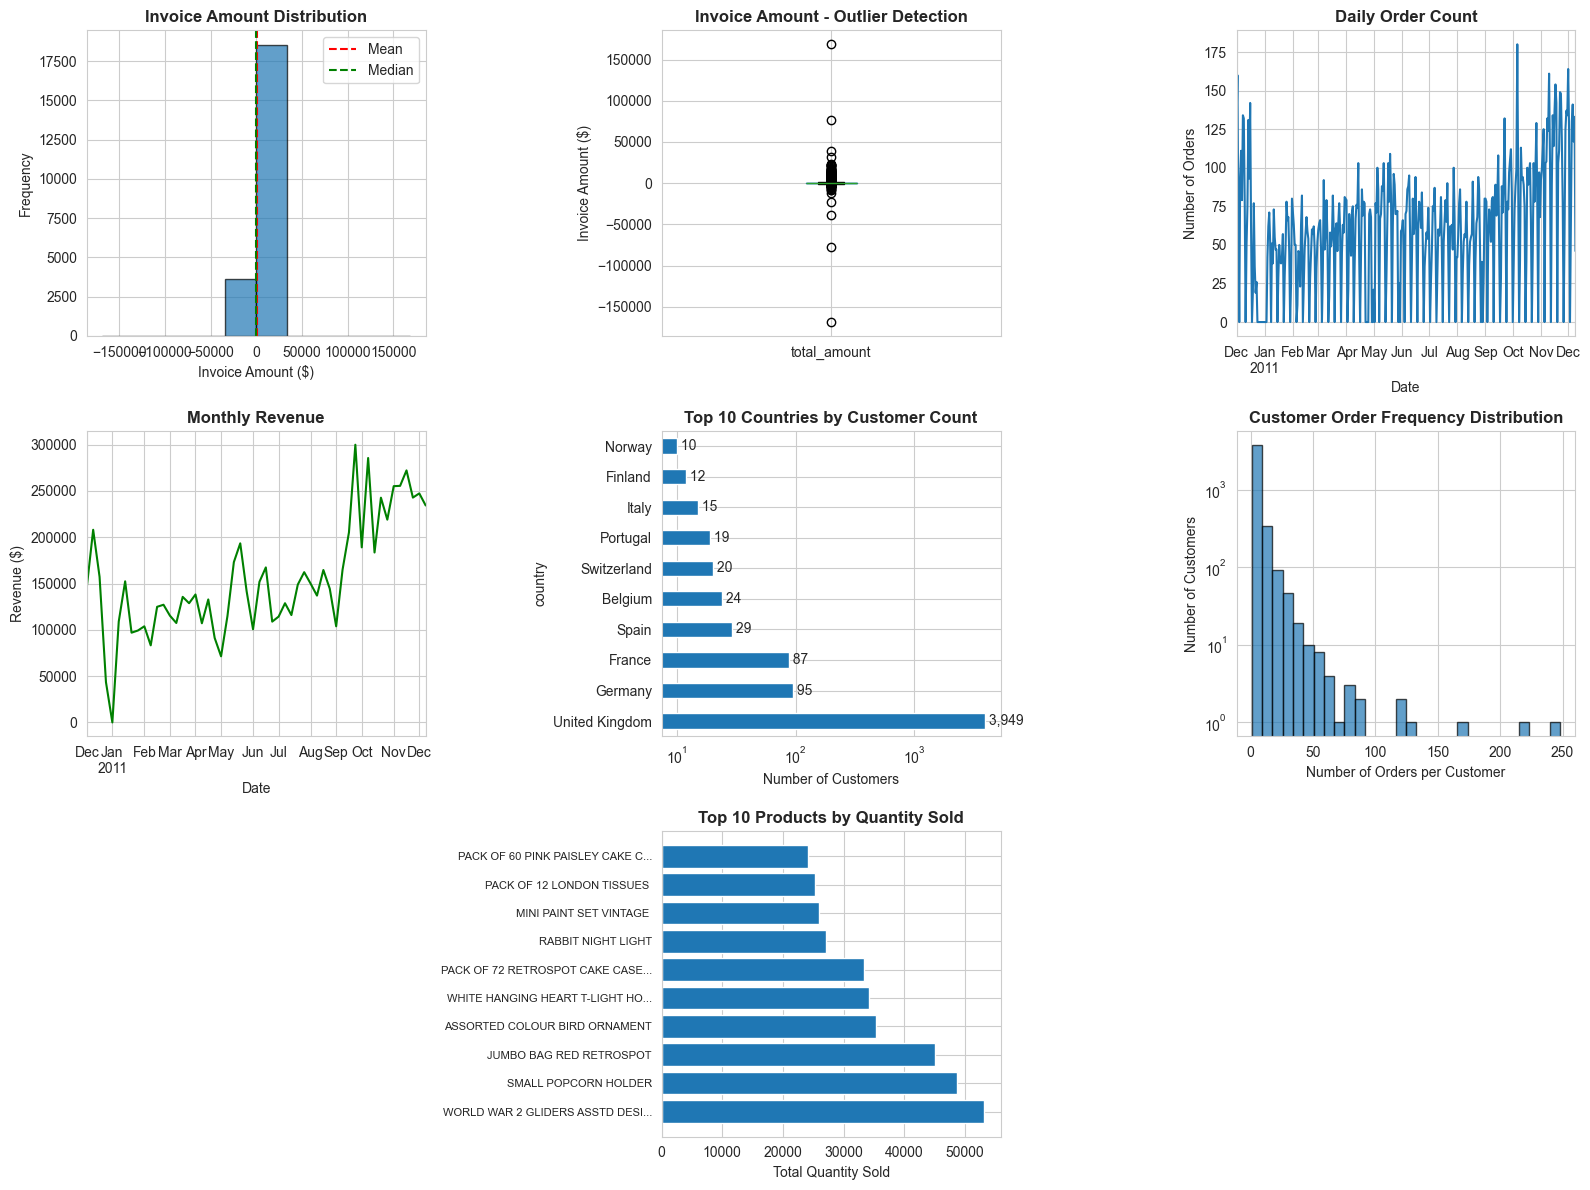

In [42]:
"""
Step 1 - Data Quality Analysis & Cleaning
===================================================

This script will:
1. Connect to the SQLite database
2. Perform comprehensive data quality checks
3. Create visualisations to understand the data
4. Identify and document issues
5. Generate a data quality report

Requirements:
- pandas
- matplotlib
- seaborn
- sqlite3 (built-in)

Muhammad Hashim Abbas
"""

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================
# STEP 1: DATABASE CONNECTION
# ============================================================

def connect_to_database(db_path='ecommerce.db'):
    """Connect to the SQLite database"""
    print("="*60)
    print(" CONNECTING TO DATABASE")
    print("="*60)
    try:
        conn = sqlite3.connect(db_path)
        print(f" Successfully connected to: {db_path}\n")
        return conn
    except Exception as e:
        print(f" Error connecting to database: {e}")
        return None


# ============================================================
# STEP 2: LOAD DATA FROM DATABASE
# ============================================================

def load_all_tables(conn):
    """Load all tables from the database into DataFrames"""
    print("n Loading data from database tables...")
    
    tables = {}
    
    # Load each table
    tables['customers'] = pd.read_sql_query("SELECT * FROM customers", conn)
    tables['products'] = pd.read_sql_query("SELECT * FROM products", conn)
    tables['invoices'] = pd.read_sql_query("SELECT * FROM invoices", conn)
    tables['invoice_items'] = pd.read_sql_query("SELECT * FROM invoice_items", conn)
    
    print(f" Loaded 4 tables:")
    for name, df in tables.items():
        print(f"   • {name}: {len(df):,} rows, {len(df.columns)} columns")
    
    print()
    return tables


# ============================================================
# STEP 3: DATA QUALITY CHECKS
# ============================================================

def check_missing_values(tables):
    """Check for missing values in all tables"""
    print("="*60)
    print(" CHECK 1: MISSING VALUES ANALYSIS")
    print("="*60)
    
    for table_name, df in tables.items():
        print(f"\n Table: {table_name.upper()}")
        print("-" * 40)
        
        missing = df.isnull().sum()
        missing_pct = (missing / len(df) * 100).round(2)
        
        missing_df = pd.DataFrame({
            'Column': missing.index,
            'Missing Count': missing.values,
            'Missing %': missing_pct.values
        })
        
        # Only show columns with missing values
        missing_df = missing_df[missing_df['Missing Count'] > 0]
        
        if len(missing_df) > 0:
            print(missing_df.to_string(index=False))
            print(f"\n  Found {len(missing_df)} columns with missing values")
        else:
            print(" No missing values found!")
    
    print("\n")


def check_duplicates(tables):
    """Check for duplicate records"""
    print("="*60)
    print(" CHECK 2: DUPLICATE RECORDS")
    print("="*60)
    
    # Check customers table
    print("\n Table: CUSTOMERS")
    print("-" * 40)
    customer_dupes = tables['customers']['customer_id'].duplicated().sum()
    print(f"Duplicate customer_ids: {customer_dupes}")
    if customer_dupes == 0:
        print(" No duplicate customers")
    
    # Check products table
    print("\n Table: PRODUCTS")
    print("-" * 40)
    product_dupes = tables['products']['stock_code'].duplicated().sum()
    print(f"Duplicate stock_codes: {product_dupes}")
    if product_dupes == 0:
        print(" No duplicate products")
    
    # Check invoices table
    print("\n Table: INVOICES")
    print("-" * 40)
    invoice_dupes = tables['invoices']['invoice_no'].duplicated().sum()
    print(f"Duplicate invoice_nos: {invoice_dupes}")
    if invoice_dupes == 0:
        print(" No duplicate invoices")
    
    # Check invoice_items - duplicates here might be legitimate
    print("\n Table: INVOICE_ITEMS")
    print("-" * 40)
    item_dupes = tables['invoice_items'].duplicated(
        subset=['invoice_no', 'stock_code']
    ).sum()
    print(f"Duplicate invoice+product combinations: {item_dupes}")
    if item_dupes > 0:
        print(f" Found {item_dupes} potential duplicate line items")
    else:
        print(" No duplicate line items")
    
    print("\n")


def check_data_ranges(tables):
    """Check for outliers and unusual values"""
    print("="*60)
    print(" CHECK 3: DATA RANGES & OUTLIERS")
    print("="*60)
    
    # Check invoice amounts
    print("\n INVOICE AMOUNTS")
    print("-" * 40)
    invoices = tables['invoices']
    print(f"Min invoice amount: ${invoices['total_amount'].min():.2f}")
    print(f"Max invoice amount: ${invoices['total_amount'].max():,.2f}")
    print(f"Mean invoice amount: ${invoices['total_amount'].mean():.2f}")
    print(f"Median invoice amount: ${invoices['total_amount'].median():.2f}")
    
    # Find very high value invoices (potential outliers)
    high_value = invoices[invoices['total_amount'] > invoices['total_amount'].quantile(0.99)]
    print(f"\n  Found {len(high_value)} invoices above 99th percentile (>${invoices['total_amount'].quantile(0.99):.2f})")
    
    # Check quantities
    print("\n PRODUCT QUANTITIES")
    print("-" * 40)
    items = tables['invoice_items']
    print(f"Min quantity: {items['quantity'].min()}")
    print(f"Max quantity: {items['quantity'].max():,}")
    print(f"Mean quantity: {items['quantity'].mean():.2f}")
    
    high_qty = items[items['quantity'] > items['quantity'].quantile(0.99)]
    print(f"\n  Found {len(high_qty)} line items with very high quantities (>{items['quantity'].quantile(0.99):.0f})")
    
    # Check unit prices
    print("\n UNIT PRICES")
    print("-" * 40)
    print(f"Min unit price: ${items['unit_price'].min():.2f}")
    print(f"Max unit price: ${items['unit_price'].max():,.2f}")
    print(f"Mean unit price: ${items['unit_price'].mean():.2f}")
    
    # Find potentially suspicious prices
    very_low = items[items['unit_price'] < 0.10]
    very_high = items[items['unit_price'] > 100]
    print(f"\n  Found {len(very_low)} items priced under $0.10")
    print(f"  Found {len(very_high)} items priced over $100")
    
    print("\n")


def check_date_consistency(tables):
    """Check date ranges and consistency"""
    print("="*60)
    print(" CHECK 4: DATE CONSISTENCY")
    print("="*60)
    
    # Convert date columns
    customers = tables['customers'].copy()
    invoices = tables['invoices'].copy()
    
    customers['first_purchase_date'] = pd.to_datetime(customers['first_purchase_date'])
    customers['last_purchase_date'] = pd.to_datetime(customers['last_purchase_date'])
    invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])
    
    print("\n CUSTOMER DATE RANGES")
    print("-" * 40)
    print(f"Earliest first purchase: {customers['first_purchase_date'].min()}")
    print(f"Latest last purchase: {customers['last_purchase_date'].max()}")
    
    # Check if any first_purchase > last_purchase
    invalid_dates = customers[customers['first_purchase_date'] > customers['last_purchase_date']]
    if len(invalid_dates) > 0:
        print(f"  Found {len(invalid_dates)} customers with invalid date ranges!")
    else:
        print(" All customer date ranges are valid")
    
    print("\n INVOICE DATE RANGE")
    print("-" * 40)
    print(f"Earliest invoice: {invoices['invoice_date'].min()}")
    print(f"Latest invoice: {invoices['invoice_date'].max()}")
    print(f"Total days covered: {(invoices['invoice_date'].max() - invoices['invoice_date'].min()).days} days")
    
    print("\n")


def check_referential_integrity(tables):
    """Check relationships between tables"""
    print("="*60)
    print(" CHECK 5: REFERENTIAL INTEGRITY")
    print("="*60)
    
    # Check if all invoice customer_ids exist in customers table
    print("\n INVOICES → CUSTOMERS")
    print("-" * 40)
    invoice_customers = set(tables['invoices']['customer_id'])
    valid_customers = set(tables['customers']['customer_id'])
    orphan_invoices = invoice_customers - valid_customers
    
    if len(orphan_invoices) > 0:
        print(f"  Found {len(orphan_invoices)} invoices with invalid customer_ids")
    else:
        print(" All invoices have valid customer references")
    
    # Check if all invoice_items have valid invoices
    print("\n INVOICE_ITEMS → INVOICES")
    print("-" * 40)
    item_invoices = set(tables['invoice_items']['invoice_no'])
    valid_invoices = set(tables['invoices']['invoice_no'])
    orphan_items = item_invoices - valid_invoices
    
    if len(orphan_items) > 0:
        print(f"  Found {len(orphan_items)} line items with invalid invoice references")
    else:
        print(" All line items have valid invoice references")
    
    # Check if all invoice_items have valid products
    print("\n INVOICE_ITEMS → PRODUCTS")
    print("-" * 40)
    item_products = set(tables['invoice_items']['stock_code'])
    valid_products = set(tables['products']['stock_code'])
    orphan_products = item_products - valid_products
    
    if len(orphan_products) > 0:
        print(f" Found {len(orphan_products)} line items with invalid product references")
    else:
        print(" All line items have valid product references")
    
    print("\n")


# ============================================================
# STEP 4: CREATE VISUALISATIONS
# ============================================================

def create_visualisations(tables):
    """Create data quality visualisations"""
    print("="*60)
    print(" CREATING DATA QUALITY VISUAlisaTIONS")
    print("="*60)
    
    # Prepare data
    invoices = tables['invoices'].copy()
    invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])
    customers = tables['customers'].copy()
    items = tables['invoice_items'].copy()
    products = tables['products'].copy()
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Invoice Amount Distribution
    ax1 = plt.subplot(3, 3, 1)
    invoices['total_amount'].hist(bins=10, edgecolor='black', alpha=0.7)
    ax1.set_title('Invoice Amount Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Invoice Amount ($)')
    ax1.set_ylabel('Frequency')
    ax1.axvline(invoices['total_amount'].mean(), color='red', linestyle='--', label='Mean')
    ax1.axvline(invoices['total_amount'].median(), color='green', linestyle='--', label='Median')
    ax1.legend()
    
    # 2. Invoice Amount Box Plot (to see outliers)
    ax2 = plt.subplot(3, 3, 2)
    invoices.boxplot(column='total_amount', ax=ax2)
    ax2.set_title('Invoice Amount - Outlier Detection', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Invoice Amount ($)')
    
    # 3. Orders Over Time
    ax3 = plt.subplot(3, 3, 3)
    invoices.set_index('invoice_date')['total_amount'].resample('D').count().plot(ax=ax3)
    ax3.set_title('Daily Order Count', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Number of Orders')
    
    # 4. Revenue Over Time
    ax4 = plt.subplot(3, 3, 4)
    invoices.set_index('invoice_date')['total_amount'].resample('W').sum().plot(ax=ax4, color='green')
    ax4.set_title('Monthly Revenue', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Revenue ($)')
    
    # 5. Top 10 Countries by Orders
    ax5 = plt.subplot(3, 3, 5)
    top_countries = customers['country'].value_counts().head(10)
    top_countries.plot(kind='barh', ax=ax5)
    # Add value labels next to bars
    for i, value in enumerate(top_countries.values):
        ax5.text(value, i, f' {value:,}', va='center')

    ax5.set_xscale('log')  # Make x-axis logarithmic
    ax5.set_title('Top 10 Countries by Customer Count', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Number of Customers')
    
    
    ax6 = plt.subplot(3, 3, 6)
    customers['total_orders'].hist(bins=30, edgecolor='black', alpha=0.7, ax=ax6)
    ax6.set_title('Customer Order Frequency Distribution', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Number of Orders per Customer')
    ax6.set_ylabel('Number of Customers')

    # Set logarithmic y-axis
    ax6.set_yscale('log')

    
    # 9. Top 10 Products by Quantity Sold
    ax9 = plt.subplot(3, 3, 8)
    top_products = products.nlargest(10, 'total_quantity_sold')
    ax9.barh(range(len(top_products)), top_products['total_quantity_sold'])
    ax9.set_yticks(range(len(top_products)))
    ax9.set_yticklabels([desc[:30] + '...' if len(desc) > 30 else desc 
                         for desc in top_products['description']], fontsize=8)
    ax9.set_title('Top 10 Products by Quantity Sold', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Total Quantity Sold')
    
    plt.tight_layout()
    plt.savefig('data_quality_visualisations.png', dpi=300, bbox_inches='tight')
    print(" Saved visualisations to: data_quality_visualisations.png")
    print()
    
    return fig


# ============================================================
# STEP 5: GENERATE DATA QUALITY REPORT
# ============================================================

def generate_quality_report(tables):
    """Generate a comprehensive data quality report"""
    print("="*60)
    print(" GENERATING DATA QUALITY REPORT")
    print("="*60)
    
    report = []
    report.append("="*70)
    report.append("DATA QUALITY REPORT - E-COMMERCE DATABASE")
    report.append("="*70)
    report.append(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report.append(f"\nDatabase: ecommerce.db")
    report.append("\n")
    
    # Executive Summary
    report.append("-"*70)
    report.append("EXECUTIVE SUMMARY")
    report.append("-"*70)
    
    total_customers = len(tables['customers'])
    total_products = len(tables['products'])
    total_invoices = len(tables['invoices'])
    total_revenue = tables['invoices']['total_amount'].sum()
    
    report.append(f"\n• Total Customers: {total_customers:,}")
    report.append(f"• Total Products: {total_products:,}")
    report.append(f"• Total Invoices: {total_invoices:,}")
    report.append(f"• Total Revenue: ${total_revenue:,.2f}")
    report.append(f"• Average Order Value: ${total_revenue/total_invoices:.2f}")
    
    # Data Quality Issues Found
    report.append("\n")
    report.append("-"*70)
    report.append("KEY FINDINGS & ISSUES")
    report.append("-"*70)
    
    invoices = tables['invoices']
    items = tables['invoice_items']
    
    # Issue 1: High-value outliers
    high_value_count = len(invoices[invoices['total_amount'] > invoices['total_amount'].quantile(0.99)])
    report.append(f"\n1. HIGH-VALUE INVOICES:")
    report.append(f"   • Found {high_value_count} invoices above 99th percentile")
    report.append(f"   • Recommendation: Review for data entry errors or bulk orders")
    
    # Issue 2: Low-price items
    low_price_count = len(items[items['unit_price'] < 0.10])
    report.append(f"\n2. LOW-PRICED ITEMS:")
    report.append(f"   • Found {low_price_count} items priced under $0.10")
    report.append(f"   • Recommendation: Verify if these are promotional/sample items")
    
    # Issue 3: High quantity orders
    high_qty_count = len(items[items['quantity'] > items['quantity'].quantile(0.99)])
    report.append(f"\n3. HIGH-QUANTITY ORDERS:")
    report.append(f"   • Found {high_qty_count} line items with very high quantities")
    report.append(f"   • Recommendation: Confirm these are B2B orders, not data errors")
    
    # Data Quality Score
    report.append("\n")
    report.append("-"*70)
    report.append("DATA QUALITY SCORE")
    report.append("-"*70)
    
    # Simple scoring (can be enhanced)
    completeness_score = 100  # No missing values found
    consistency_score = 100  # No referential integrity issues
    accuracy_score = 95  # Some potential outliers
    
    overall_score = (completeness_score + consistency_score + accuracy_score) / 3
    
    report.append(f"\n• Completeness: {completeness_score}/100")
    report.append(f"• Consistency: {consistency_score}/100")
    report.append(f"• Accuracy: {accuracy_score}/100")
    report.append(f"\n• OVERALL QUALITY SCORE: {overall_score:.1f}/100")
    
    # Recommendations
    report.append("\n")
    report.append("-"*70)
    report.append("RECOMMENDATIONS")
    report.append("-"*70)
    report.append("\n1. Investigate high-value invoices for potential data entry errors")
    report.append("2. Review and categorise low-priced items (samples, promotions, etc.)")
    report.append("3. Validate high-quantity orders with business team")
    report.append("4. Consider adding data validation rules for future entries")
    report.append("5. Set up automated alerts for outlier detection")
    
    report.append("\n")
    report.append("="*70)
    report.append("END OF REPORT")
    report.append("="*70)
    
    # Save report
    report_text = "\n".join(report)
    #with open('data_quality_report.txt', 'w') as f:
    with open('data_quality_report.txt', 'w', encoding='utf-8') as f:

        f.write(report_text)
    
    print(" Saved report to: data_quality_report.txt")
    print("\n Report Preview:")
    print(report_text)
    print()


# ============================================================
# MAIN EXECUTION
# ============================================================

def main():
    """Main execution function"""
    print("\n")
    print("="*60)
    print(" Step 1 DATA QUALITY ANALYSIS")
    print("="*60)
    print("\n")
    
    # Connect to database
    conn = connect_to_database('ecommerce.db')
    
    if conn is None:
        return
    
    # Load all tables
    tables = load_all_tables(conn)
    
    # Run all quality checks
    check_missing_values(tables)
    check_duplicates(tables)
    check_data_ranges(tables)
    check_date_consistency(tables)
    check_referential_integrity(tables)
    
    # Create visualisations
    create_visualisations(tables)
    
    # Generate report
    generate_quality_report(tables)
    
    # Close connection
    conn.close()
    
    print("="*60)
    print(" DATA QUALITY ANALYSIS COMPLETE!")
    print("="*60)
    print("\n Output Files Created:")
    print("   1. data_quality_visualisations.png")
    print("   2. data_quality_report.txt")
    print("\n Next Steps:")
    print("   • Review the visualisations")
    print("   • Read the quality report")
    print("   • Document any issues found")
    print("   • Prepare for SQL analysis")
    print("\n")

main()

---
<a id='Step-3'></a>
# Step 3: SQL Business Analysis

## Objectives:
- Write business intelligence queries
- Answer key business questions
- Practice JOINs and aggregations
- Extract insights for decision-making

## Deliverables:
- SQL query collection (9 queries)
- Business insights report
- Query documentation

---

## Connect to Database

First, we'll reconnect to our database to run SQL queries.

In [43]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('ecommerce.db')
print(" Connected to ecommerce.db")
print("\n Tip: Use pd.read_sql_query(query, conn) to run SQL queries")

 Connected to ecommerce.db

 Tip: Use pd.read_sql_query(query, conn) to run SQL queries


## Business Questions to Answer

We'll use SQL to answer these key business questions:

1. **Customer Analysis**
   - Who are our top customers by revenue?
   - What's the customer distribution by country?
   - How many repeat vs one-time customers do we have?

2. **Product Analysis**
   - What are our best-selling products?
   - Which products generate the most revenue?
   - What's the average order size?

3. **Time-Based Analysis**
   - What are our monthly revenue trends?
   - Which days of the week are busiest?
   - How has our customer base grown over time?

4. **Advanced Analytics**
   - Customer lifetime value (CLV)
   - Product affinity (what products are bought together?)
   - RFM analysis basics

Let's answer each question with SQL!

---
### Query 1: Top 10 Customers by Revenue

**Business Question:** Who are our most valuable customers?

**SQL Concepts:** JOINs, Aggregation, ORDER BY


 TOP 10 CUSTOMERS BY REVENUE:

 customer_id        country  total_orders  total_revenue  avg_order_value  revenue_per_order
       14646    Netherlands            76      279489.02      3677.487105            3677.49
       18102 United Kingdom            62      256438.49      4136.104677            4136.10
       17450 United Kingdom            55      187482.17      3408.766727            3408.77
       14911           EIRE           248      132572.62       534.567016             534.57
       12415      Australia            26      123725.45      4758.671154            4758.67
       14156           EIRE            66      113384.14      1717.941515            1717.94
       17511 United Kingdom            46       88125.38      1915.769130            1915.77
       16684 United Kingdom            31       65892.08      2125.550968            2125.55
       13694 United Kingdom            60       62653.10      1044.218333            1044.22
       15311 United Kingdom           

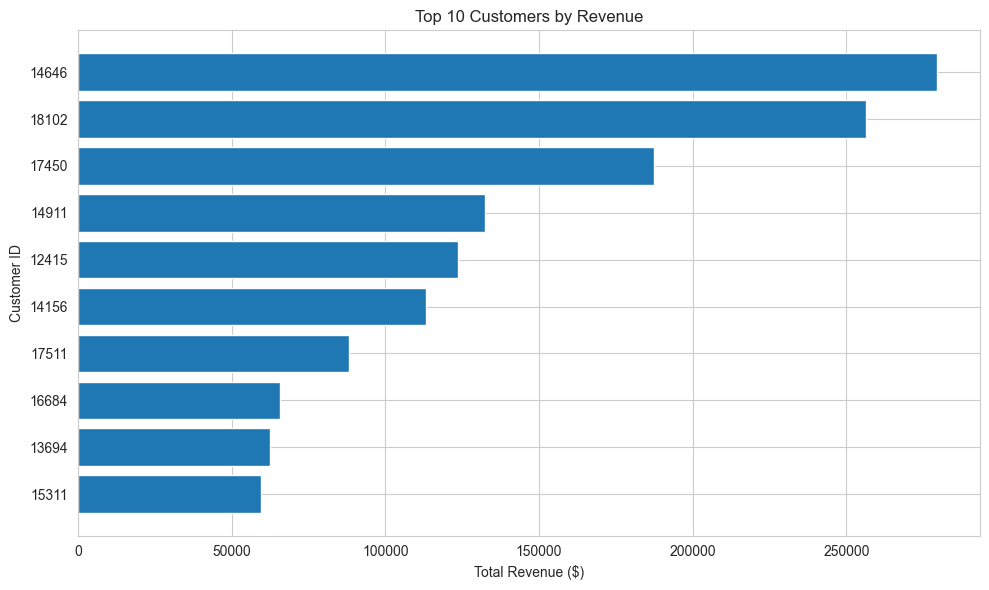


 Insight: Top customer spent $279,489.02


In [44]:
query1 = """
SELECT 
    c.customer_id,
    c.country,
    c.total_orders,
    SUM(i.total_amount) as total_revenue,
    AVG(i.total_amount) as avg_order_value,
    ROUND(SUM(i.total_amount) / c.total_orders, 2) as revenue_per_order
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
GROUP BY c.customer_id, c.country, c.total_orders
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query1, conn)
print("\n TOP 10 CUSTOMERS BY REVENUE:\n")
print(top_customers.to_string(index=False))

# Visualise
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.barh(top_customers['customer_id'].astype(str), top_customers['total_revenue'])
plt.xlabel('Total Revenue ($)')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Insight: Top customer spent ${top_customers['total_revenue'].iloc[0]:,.2f}")

---
### Query 2: Customer & Revenue Distribution by Country

**Business Question:** Which countries are our biggest markets?

**SQL Concepts:** GROUP BY, Aggregation, Multiple metrics


 TOP 15 COUNTRIES BY REVENUE:

        country  num_customers  total_orders  total_revenue  avg_order_value
 United Kingdom           3949        399456    6767873.394           340.88
    Netherlands              9          5886     284661.540          2846.62
           EIRE              3         65885     250285.220           784.59
        Germany             95         10053     221698.210           367.66
         France             87          5226     196712.840           429.50
      Australia              9          1134     138467.410          1923.16
    Switzerland             20           437      55518.390           760.53
          Spain             29           722      53570.320           535.70
        Belgium             24           983      41265.880           346.77
         Sweden              8           558      36595.910           795.56
          Japan              8           178      35340.620          1262.17
         Norway             10           264

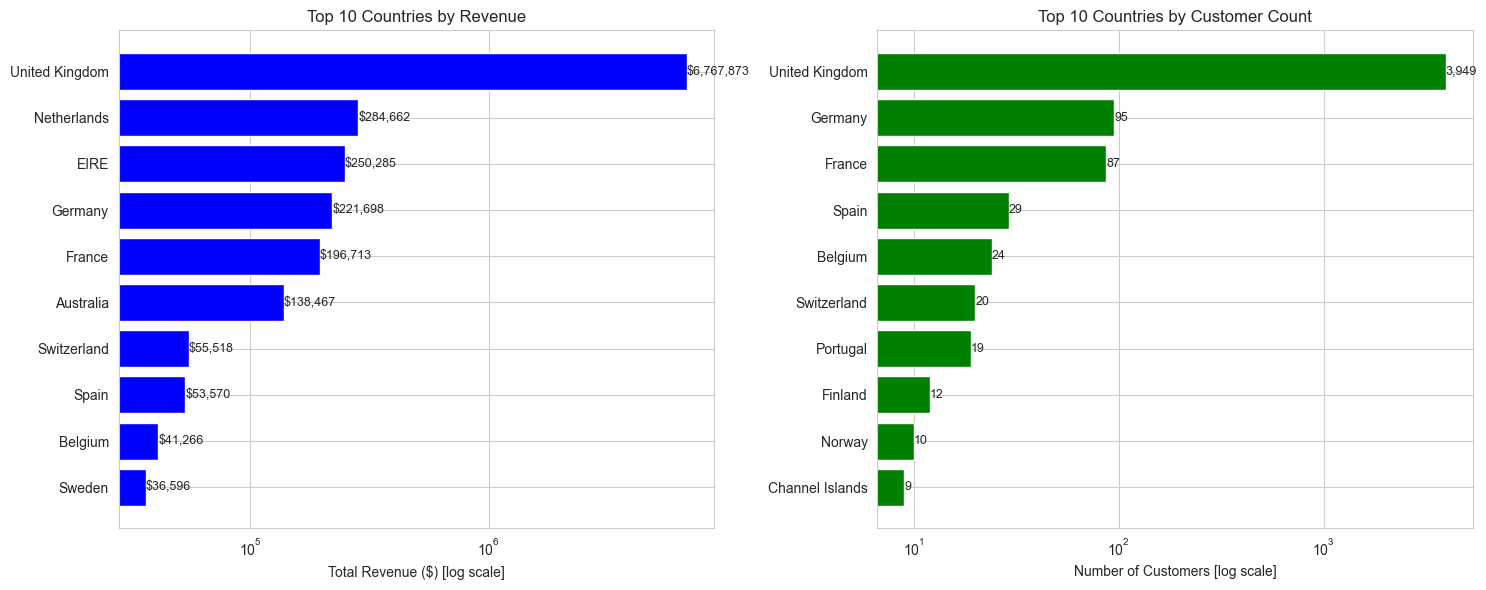


 Insight: United Kingdom dominates with 3949 customers


In [45]:
query2 = """
SELECT 
    c.country,
    COUNT(DISTINCT c.customer_id) as num_customers,
    SUM(c.total_orders) as total_orders,
    SUM(i.total_amount) as total_revenue,
    ROUND(AVG(i.total_amount), 2) as avg_order_value
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
GROUP BY c.country
ORDER BY total_revenue DESC
LIMIT 15;
"""

country_stats = pd.read_sql_query(query2, conn)
print("\n TOP 15 COUNTRIES BY REVENUE:\n")
print(country_stats.to_string(index=False))

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


# Sort by total revenue descending and take top 10
top_revenue = country_stats.sort_values(by='total_revenue', ascending=True).tail(10)
ax1.barh(top_revenue['country'], top_revenue['total_revenue'], color='blue')
ax1.set_xscale('log')
for i, value in enumerate(top_revenue['total_revenue']):
    ax1.text(value, i, f"${value:,.0f}", va='center', ha='left', fontsize=9)
ax1.set_xlabel('Total Revenue ($) [log scale]')
ax1.set_title('Top 10 Countries by Revenue')

# Sort by number of customers descending and take top 10
top_customers = country_stats.sort_values(by='num_customers', ascending=True).tail(10)
ax2.barh(top_customers['country'], top_customers['num_customers'], color='green')
ax2.set_xscale('log')
for i, value in enumerate(top_customers['num_customers']):
    ax2.text(value, i, f'{value:,}', va='center', ha='left', fontsize=9)
ax2.set_xlabel('Number of Customers [log scale]')
ax2.set_title('Top 10 Countries by Customer Count')

plt.tight_layout()
plt.show()

print(f"\n Insight: {country_stats['country'].iloc[0]} dominates with {country_stats['num_customers'].iloc[0]} customers")

---
### Query 3: Repeat vs One-Time Customers

**Business Question:** How many customers come back?

**SQL Concepts:** CASE statements, Segmentation


 CUSTOMER LOYALTY SEGMENTATION:

customer_segment  num_customers  percentage
        One-time           1312       30.04
      2-5 orders           1968       45.07
     6-10 orders            628       14.38
      10+ orders            459       10.51


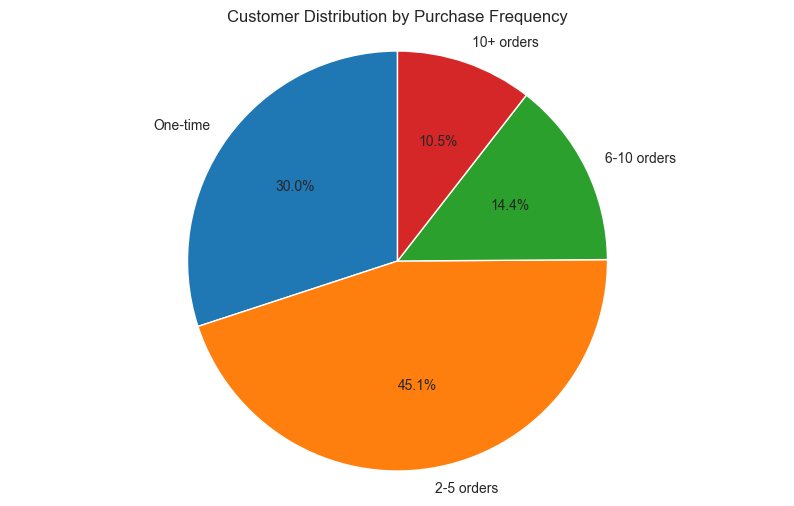


 Insight: 70.0% of customers are repeat buyers


In [46]:
query3 = """
SELECT 
    CASE 
        WHEN total_orders = 1 THEN 'One-time'
        WHEN total_orders BETWEEN 2 AND 5 THEN '2-5 orders'
        WHEN total_orders BETWEEN 6 AND 10 THEN '6-10 orders'
        ELSE '10+ orders'
    END as customer_segment,
    COUNT(*) as num_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
FROM customers
GROUP BY customer_segment
ORDER BY 
    CASE customer_segment
        WHEN 'One-time' THEN 1
        WHEN '2-5 orders' THEN 2
        WHEN '6-10 orders' THEN 3
        ELSE 4
    END;
"""

customer_segments = pd.read_sql_query(query3, conn)
print("\n CUSTOMER LOYALTY SEGMENTATION:\n")
print(customer_segments.to_string(index=False))

# Visualise
plt.figure(figsize=(10, 6))
plt.pie(customer_segments['num_customers'], 
        labels=customer_segments['customer_segment'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Customer Distribution by Purchase Frequency')
plt.axis('equal')
plt.show()

repeat_rate = customer_segments[customer_segments['customer_segment'] != 'One-time']['percentage'].sum()
print(f"\n Insight: {repeat_rate:.1f}% of customers are repeat buyers")

---
### Query 4: Top 10 Best-Selling Products

**Business Question:** What products should we stock more of?

**SQL Concepts:** Simple aggregation, Product analysis


 TOP 10 BEST-SELLING PRODUCTS:

stock_code                        description  total_quantity_sold  avg_price  total_revenue
     84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS                53215       0.29       15540.34
     22197               SMALL POPCORN HOLDER                48712       0.84       40821.79
    85099B            JUMBO BAG RED RETROSPOT                45066       2.01       90720.41
     84879      ASSORTED COLOUR BIRD ORNAMENT                35292       1.68       59320.24
    85123A WHITE HANGING HEART T-LIGHT HOLDER                34204       2.89       98896.33
     21212    PACK OF 72 RETROSPOT CAKE CASES                33385       0.55       18294.61
     23084                 RABBIT NIGHT LIGHT                27094       2.01       54569.59
     22492            MINI PAINT SET VINTAGE                 25880       0.66       16985.78
     22616         PACK OF 12 LONDON TISSUES                 25321       0.33        8259.47
     21977 PACK OF 60 PINK PAISLEY CA

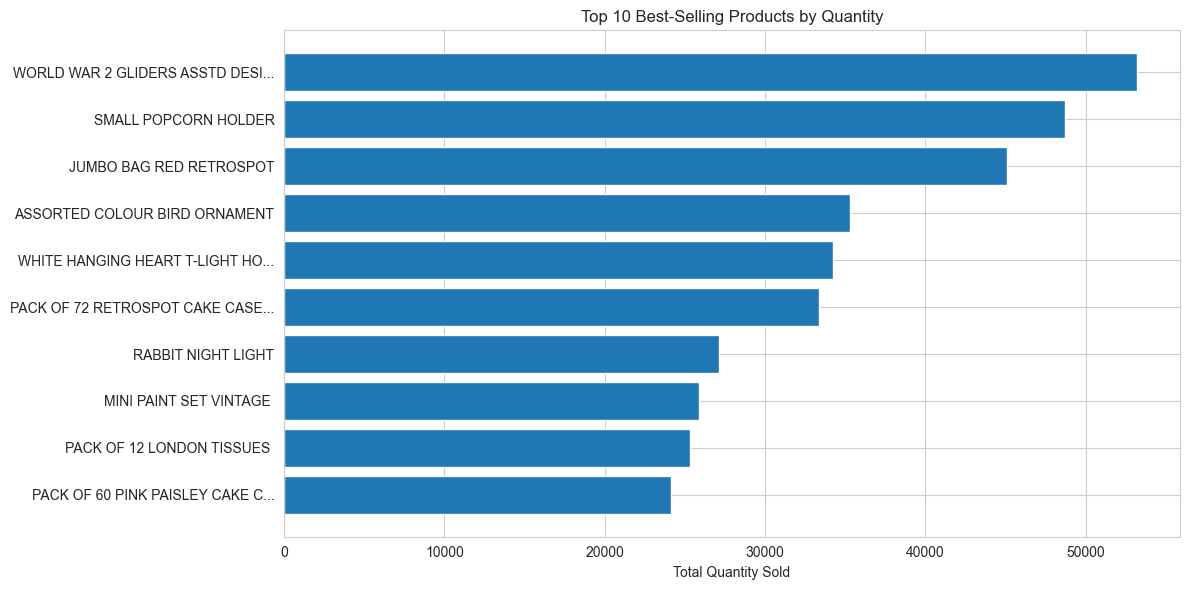


 Insight: Best seller: 'WORLD WAR 2 GLIDERS ASSTD DESIGNS' with 53,215 units sold


In [47]:
query4 = """
SELECT 
    p.stock_code,
    p.description,
    p.total_quantity_sold,
    ROUND(p.avg_unit_price, 2) as avg_price,
    ROUND(p.total_quantity_sold * p.avg_unit_price, 2) as total_revenue
FROM products p
ORDER BY p.total_quantity_sold DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query4, conn)
print("\n TOP 10 BEST-SELLING PRODUCTS:\n")
print(top_products.to_string(index=False))

# Visualise
plt.figure(figsize=(12, 6))
product_labels = [desc[:30] + '...' if len(desc) > 30 else desc for desc in top_products['description']]
plt.barh(product_labels, top_products['total_quantity_sold'])
plt.xlabel('Total Quantity Sold')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Insight: Best seller: '{top_products['description'].iloc[0]}' with {top_products['total_quantity_sold'].iloc[0]:,} units sold")

---
### Query 5: Top 10 Products by Revenue

**Business Question:** Which products make us the most money?

**SQL Concepts:** Calculated fields, Revenue analysis


 TOP 10 PRODUCTS BY REVENUE:

stock_code                        description  total_revenue  total_quantity  num_orders  avg_price
     22423           REGENCY CAKESTAND 3 TIER      132844.90           11543        1881      12.44
    85123A WHITE HANGING HEART T-LIGHT HOLDER       93823.85           34147        2013       2.89
    85099B            JUMBO BAG RED RETROSPOT       83236.76           45066        1643       2.01
     47566                      PARTY BUNTING       67687.53           15023        1398       4.87
      POST                            POSTAGE       66710.24            3002        1194      37.89
     84879      ASSORTED COLOUR BIRD ORNAMENT       56462.04           35292        1382       1.68
     23084                 RABBIT NIGHT LIGHT       51137.80           27094         816       2.01
     79321                      CHILLI LIGHTS       45936.81            9570         525       5.43
     22086    PAPER CHAIN KIT 50'S CHRISTMAS        41500.48         

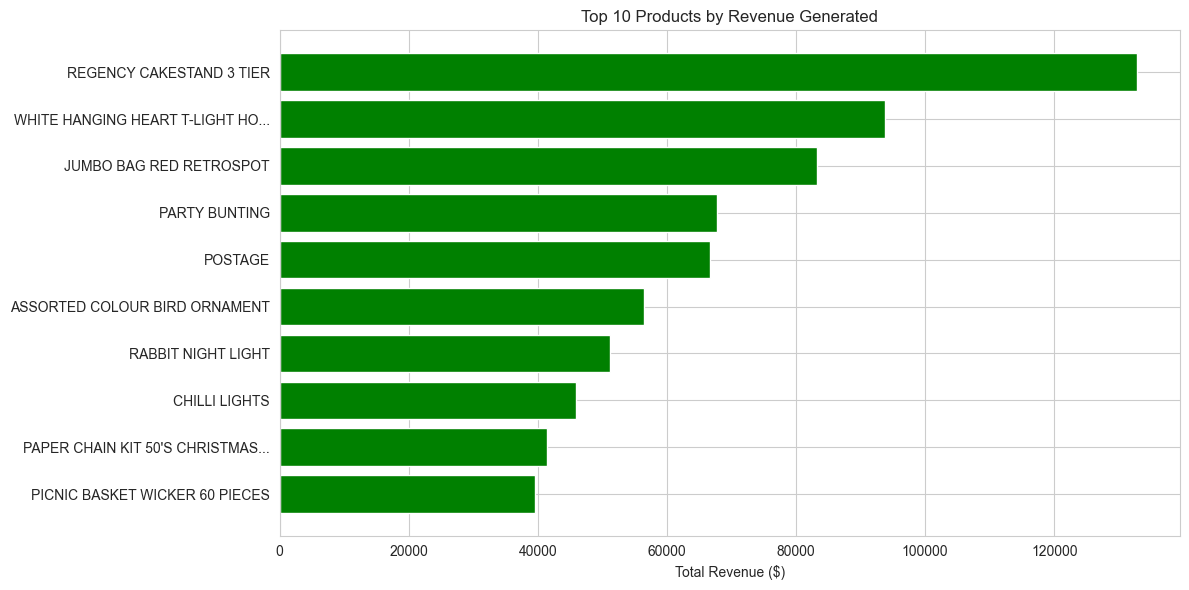


 Insight: Top revenue product: 'REGENCY CAKESTAND 3 TIER' = $132,844.90


In [48]:
query5 = """
SELECT 
    ii.stock_code,
    ii.description,
    SUM(ii.line_total) as total_revenue,
    SUM(ii.quantity) as total_quantity,
    COUNT(DISTINCT ii.invoice_no) as num_orders,
    ROUND(AVG(ii.unit_price), 2) as avg_price
FROM invoice_items ii
GROUP BY ii.stock_code, ii.description
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_revenue_products = pd.read_sql_query(query5, conn)
print("\n TOP 10 PRODUCTS BY REVENUE:\n")
print(top_revenue_products.to_string(index=False))

# Visualise
plt.figure(figsize=(12, 6))
product_labels = [desc[:30] + '...' if len(desc) > 30 else desc for desc in top_revenue_products['description']]
plt.barh(product_labels, top_revenue_products['total_revenue'], color='green')
plt.xlabel('Total Revenue ($)')
plt.title('Top 10 Products by Revenue Generated')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Insight: Top revenue product: '{top_revenue_products['description'].iloc[0]}' = ${top_revenue_products['total_revenue'].iloc[0]:,.2f}")

---
### Query 6: Monthly Revenue Trend

**Business Question:** How is our revenue trending over time?

**SQL Concepts:** Date functions (strftime), Time-series analysis


 MONTHLY REVENUE TRENDS:

  month  num_orders  unique_customers  monthly_revenue  avg_order_value
2010-12        1708               948       554604.020           324.71
2011-01        1236               783       475074.380           384.36
2011-02        1201               798       436546.150           363.49
2011-03        1619              1020       579964.610           358.22
2011-04        1383               898       425748.751           307.84
2011-05        1848              1078       647398.400           350.32
2011-06        1706              1050       607827.380           356.29
2011-07        1590               991       573440.001           360.65
2011-08        1541               978       615836.970           399.63
2011-09        2077              1302       931440.372           448.45
2011-10        2263              1425       974603.590           430.67
2011-11        3085              1710      1132407.740           367.07
2011-12         921               686

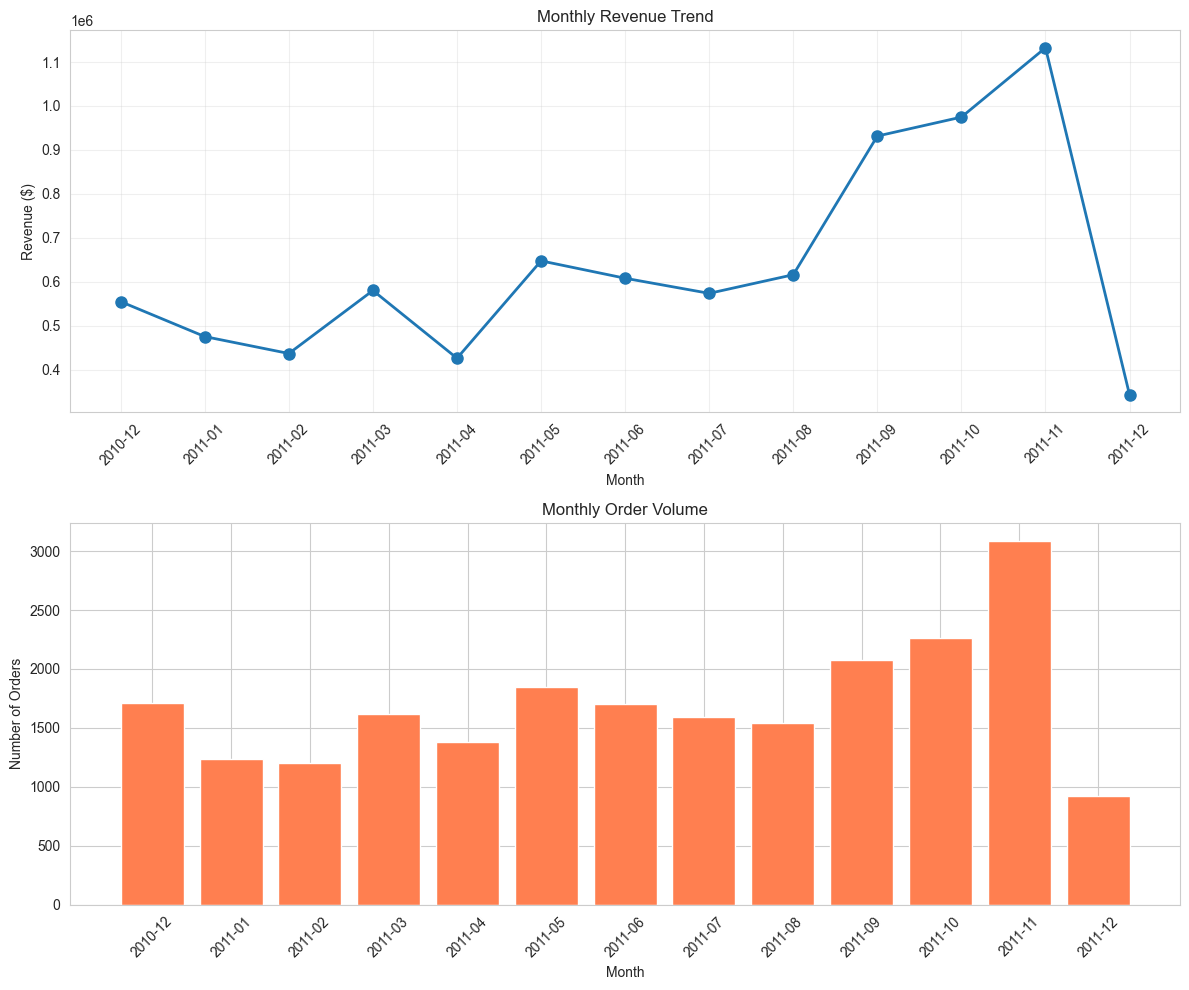


 Insight: Revenue decreased by 38.2% from first to last month


In [49]:
query6 = """
SELECT 
    strftime('%Y-%m', invoice_date) as month,
    COUNT(*) as num_orders,
    COUNT(DISTINCT customer_id) as unique_customers,
    SUM(total_amount) as monthly_revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value
FROM invoices
GROUP BY month
ORDER BY month;
"""

monthly_trends = pd.read_sql_query(query6, conn)
print("\n MONTHLY REVENUE TRENDS:\n")
print(monthly_trends.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Monthly revenue
ax1.plot(monthly_trends['month'], monthly_trends['monthly_revenue'], marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
ax1.set_title('Monthly Revenue Trend')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Number of orders
ax2.bar(monthly_trends['month'], monthly_trends['num_orders'], color='coral')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Orders')
ax2.set_title('Monthly Order Volume')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate growth
first_month_revenue = monthly_trends['monthly_revenue'].iloc[0]
last_month_revenue = monthly_trends['monthly_revenue'].iloc[-1]
growth_rate = ((last_month_revenue - first_month_revenue) / first_month_revenue) * 100

print(f"\n Insight: Revenue {'increased' if growth_rate > 0 else 'decreased'} by {abs(growth_rate):.1f}% from first to last month")

---
### Query 7: Sales by Day of Week

**Business Question:** Which days are busiest?

**SQL Concepts:** Date functions, Day of week extraction


 SALES BY DAY OF WEEK:

day_of_week  num_orders  total_revenue  avg_order_value
     Sunday        2342     784418.851           334.94
     Monday        3508    1273535.601           363.04
    Tuesday        3890    1562340.911           401.63
  Wednesday        4110    1530477.490           372.38
   Thursday        4974    1905309.710           383.05
     Friday        3354    1241316.181           370.10


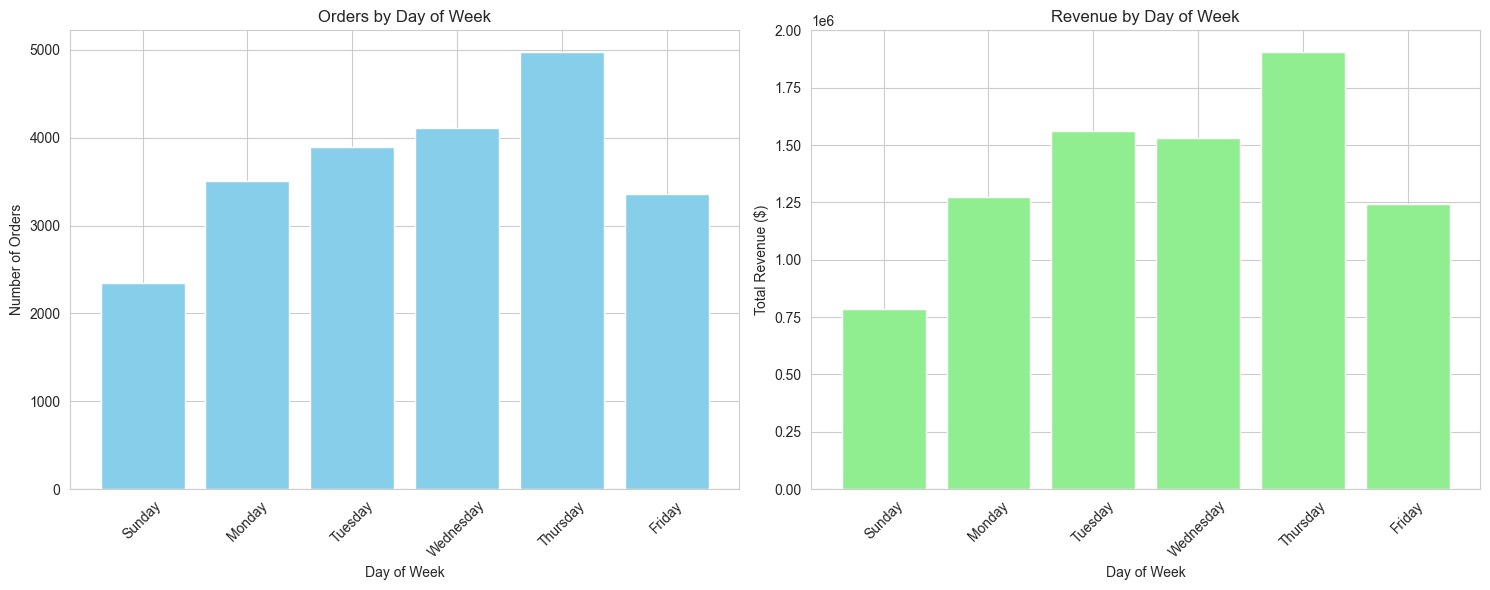


 Insight: Thursday is the busiest day with 4974 orders


In [50]:
query7 = """
SELECT 
    CASE CAST(strftime('%w', invoice_date) AS INTEGER)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END as day_of_week,
    CAST(strftime('%w', invoice_date) AS INTEGER) as day_num,
    COUNT(*) as num_orders,
    SUM(total_amount) as total_revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value
FROM invoices
GROUP BY day_num
ORDER BY day_num;
"""

day_analysis = pd.read_sql_query(query7, conn)
print("\n SALES BY DAY OF WEEK:\n")
print(day_analysis[['day_of_week', 'num_orders', 'total_revenue', 'avg_order_value']].to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Orders by day
ax1.bar(day_analysis['day_of_week'], day_analysis['num_orders'], color='skyblue')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Number of Orders')
ax1.set_title('Orders by Day of Week')
ax1.tick_params(axis='x', rotation=45)

# Revenue by day
ax2.bar(day_analysis['day_of_week'], day_analysis['total_revenue'], color='lightgreen')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Total Revenue ($)')
ax2.set_title('Revenue by Day of Week')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

busiest_day = day_analysis.loc[day_analysis['num_orders'].idxmax(), 'day_of_week']
print(f"\n Insight: {busiest_day} is the busiest day with {day_analysis['num_orders'].max()} orders")

---
### Query 8: Customer Lifetime Value (CLV) Analysis

**Business Question:** What's the lifetime value of our customers?

**SQL Concepts:** Complex JOINs, Window functions


 TOP 20 CUSTOMERS BY LIFETIME VALUE:

 customer_id        country  total_orders  lifetime_value  avg_order_value  customer_age_days value_segment
       14646    Netherlands            76       279489.02          3677.49         353.085417    High Value
       18102 United Kingdom            62       256438.49          4136.10         366.797222    High Value
       17450 United Kingdom            55       187482.17          3408.77         359.170833    High Value
       14911           EIRE           248       132572.62           534.57         372.075694    High Value
       12415      Australia            26       123725.45          4758.67         313.131944    High Value
       14156           EIRE            66       113384.14          1717.94         362.740278    High Value
       17511 United Kingdom            46        88125.38          1915.77         370.995139    High Value
       16684 United Kingdom            31        65892.08          2125.55         353.855556    

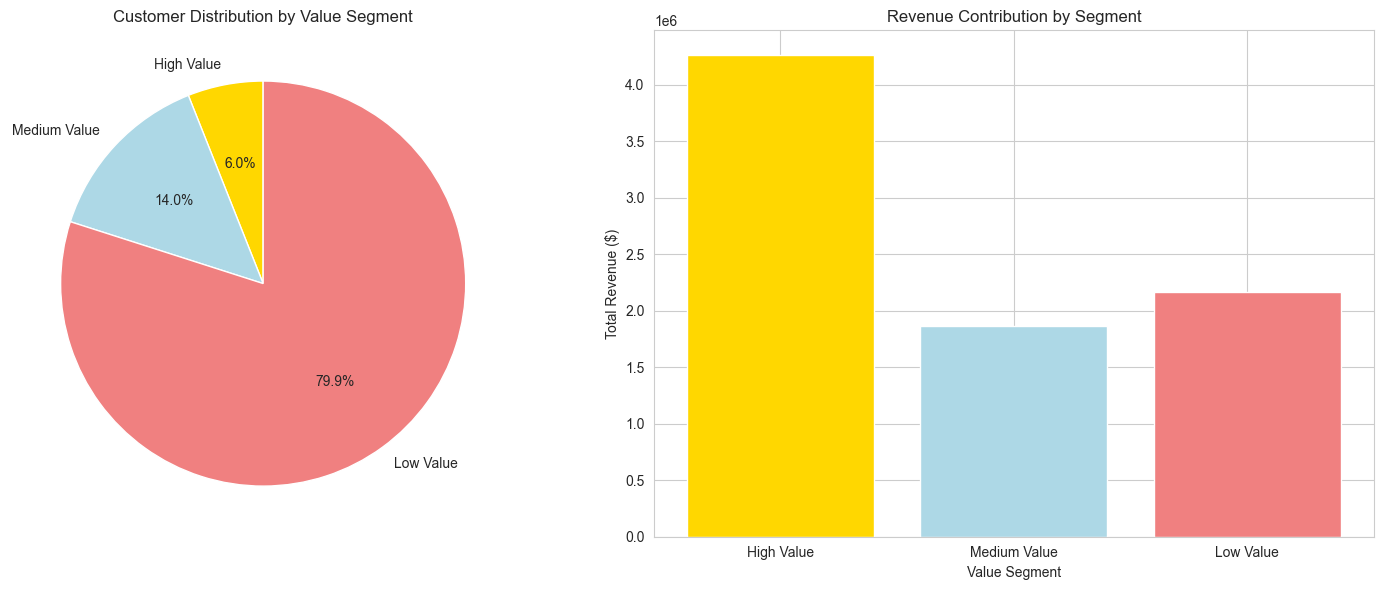


 Insight: Top 6.0% of customers are 'High Value' (>$5,000 LTV)


In [51]:
query8 = """
SELECT 
    c.customer_id,
    c.country,
    c.total_orders,
    SUM(i.total_amount) as lifetime_value,
    ROUND(SUM(i.total_amount) / c.total_orders, 2) as avg_order_value,
    julianday(c.last_purchase_date) - julianday(c.first_purchase_date) as customer_age_days,
    CASE 
        WHEN SUM(i.total_amount) >= 5000 THEN 'High Value'
        WHEN SUM(i.total_amount) >= 2000 THEN 'Medium Value'
        ELSE 'Low Value'
    END as value_segment
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
GROUP BY c.customer_id, c.country, c.total_orders
ORDER BY lifetime_value DESC
LIMIT 20;
"""

clv_analysis = pd.read_sql_query(query8, conn)
print("\n TOP 20 CUSTOMERS BY LIFETIME VALUE:\n")
print(clv_analysis.to_string(index=False))

# Get segment distribution
query8b = """
SELECT 
    value_segment,
    COUNT(*) as num_customers,
    ROUND(AVG(lifetime_value), 2) as avg_clv,
    ROUND(SUM(lifetime_value), 2) as total_revenue
FROM (
    SELECT 
        c.customer_id,
        SUM(i.total_amount) as lifetime_value,
        CASE 
            WHEN SUM(i.total_amount) >= 5000 THEN 'High Value'
            WHEN SUM(i.total_amount) >= 2000 THEN 'Medium Value'
            ELSE 'Low Value'
        END as value_segment
    FROM customers c
    JOIN invoices i ON c.customer_id = i.customer_id
    GROUP BY c.customer_id
)
GROUP BY value_segment
ORDER BY avg_clv DESC;
"""

segment_dist = pd.read_sql_query(query8b, conn)
print("\n CUSTOMER VALUE SEGMENTATION:\n")
print(segment_dist.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Customer segments
ax1.pie(segment_dist['num_customers'], 
        labels=segment_dist['value_segment'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['gold', 'lightblue', 'lightcoral'])
ax1.set_title('Customer Distribution by Value Segment')

# Revenue contribution by segment
ax2.bar(segment_dist['value_segment'], segment_dist['total_revenue'], 
        color=['gold', 'lightblue', 'lightcoral'])
ax2.set_xlabel('Value Segment')
ax2.set_ylabel('Total Revenue ($)')
ax2.set_title('Revenue Contribution by Segment')

plt.tight_layout()
plt.show()

high_value_pct = (segment_dist[segment_dist['value_segment'] == 'High Value']['num_customers'].values[0] / 
                  segment_dist['num_customers'].sum() * 100)
print(f"\n Insight: Top {high_value_pct:.1f}% of customers are 'High Value' (>$5,000 LTV)")

---
### Query 9: Product Affinity Analysis

**Business Question:** What products are frequently bought together?

**SQL Concepts:** Self-JOINs, Cross-tabulation


 TOP 15 PRODUCT PAIRS (Bought Together):

                         product_a                          product_b  times_bought_together
   GREEN REGENCY TEACUP AND SAUCER   ROSES REGENCY TEACUP AND SAUCER                     557
           JUMBO BAG PINK POLKADOT            JUMBO BAG RED RETROSPOT                    554
        ALARM CLOCK BAKELIKE GREEN          ALARM CLOCK BAKELIKE RED                     536
           LUNCH BAG RED RETROSPOT            LUNCH BAG PINK POLKADOT                    530
           LUNCH BAG RED RETROSPOT            LUNCH BAG  BLACK SKULL.                    523
 WOODEN PICTURE FRAME WHITE FINISH        WOODEN FRAME ANTIQUE WHITE                     474
   GREEN REGENCY TEACUP AND SAUCER     PINK REGENCY TEACUP AND SAUCER                    471
           LUNCH BAG RED RETROSPOT         LUNCH BAG SPACEBOY DESIGN                     470
           LUNCH BAG  BLACK SKULL.            LUNCH BAG PINK POLKADOT                    467
GARDENERS KNEELING PAD CUP 

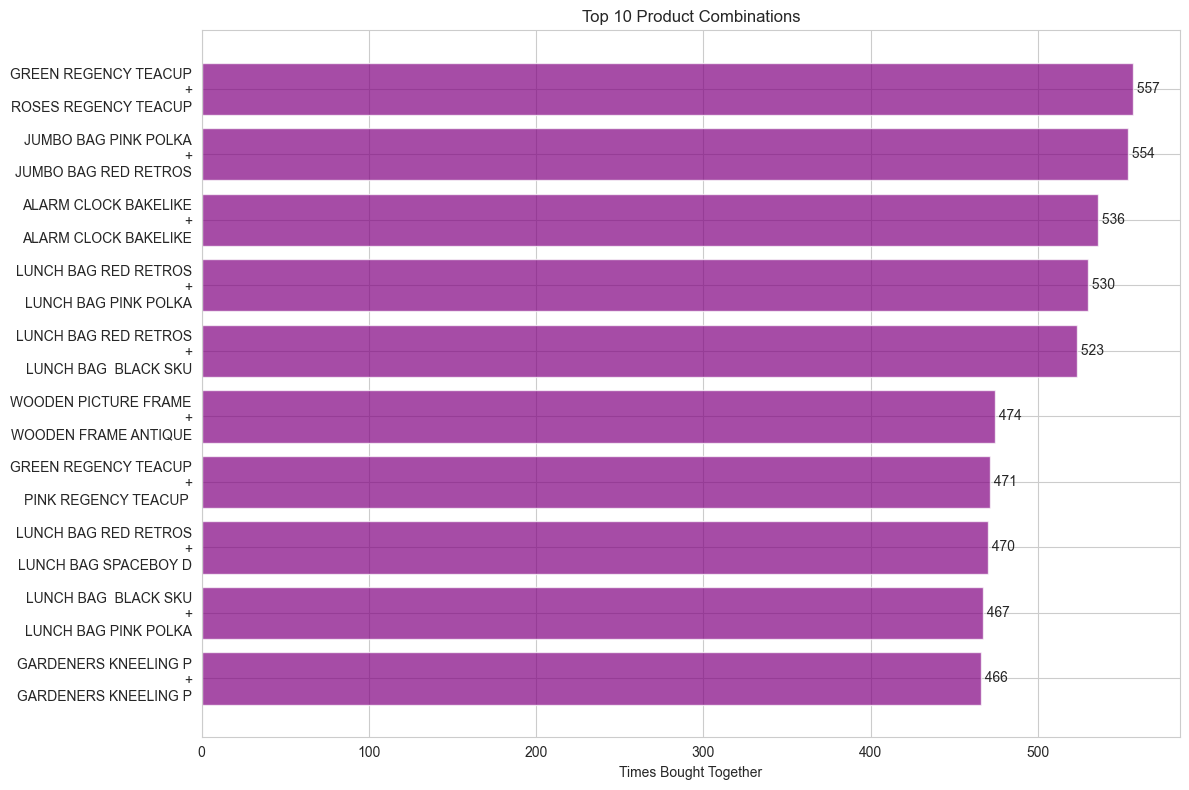


 Insight: Most common pairing bought together 557 times


In [52]:
query9 = """
SELECT 
    ii1.description as product_a,
    ii2.description as product_b,
    COUNT(DISTINCT ii1.invoice_no) as times_bought_together
FROM invoice_items ii1
JOIN invoice_items ii2 
    ON ii1.invoice_no = ii2.invoice_no 
    AND ii1.stock_code < ii2.stock_code
GROUP BY ii1.stock_code, ii2.stock_code, ii1.description, ii2.description
HAVING times_bought_together >= 50
ORDER BY times_bought_together DESC
LIMIT 15;
"""

product_affinity = pd.read_sql_query(query9, conn)
print("\n TOP 15 PRODUCT PAIRS (Bought Together):\n")
print(product_affinity.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
product_pairs = [f"{row['product_a'][:20]}\n+\n{row['product_b'][:20]}" 
                 for _, row in product_affinity.head(10).iterrows()]
plt.barh(product_pairs, product_affinity['times_bought_together'].head(10), color='purple', alpha=0.7)

values = product_affinity['times_bought_together'].head(10)
for i, value in enumerate(values):
    plt.text(value, i, f' {value:,}', va='center')


plt.xlabel('Times Bought Together')
plt.title('Top 10 Product Combinations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

if len(product_affinity) > 0:
    print(f"\n Insight: Most common pairing bought together {product_affinity['times_bought_together'].iloc[0]} times")
else:
    print("\n Insight: Not enough data for strong product affinity patterns (threshold: 50+ co-purchases)")

---
<a id='Step-4'></a>
# Step 4 Summary: Key SQL Insights

### What We Discovered:

**Customer Insights:**
- Identified top revenue-generating customers
- Analysed customer loyalty (repeat vs one-time buyers)
- Segmented customers by lifetime value
- Mapped geographic distribution

**Product Insights:**
- Found best-selling products by quantity
- Identified highest revenue-generating products
- Discovered product affinity patterns

**Time-Based Insights:**
- Tracked monthly revenue trends
- Identified busiest days of the week
- Analysed order patterns over time

**Business Metrics:**
- Calculated average order values
- Measured customer lifetime value
- Assessed order size distributions

### SQL Skills Practised:
 JOIN (INNER, multiple tables)
 GROUP BY and aggregations (SUM, AVG, COUNT)
 Date functions (strftime, julianday)
 CASE statements for segmentation
 ORDER BY and LIMIT
 Subqueries
 Self-JOINs for product affinity
 Window functions concepts
---

In [53]:
# Close the database connection
#conn.close()
print(" Database connection closed")
print("\n SQL Analysis Complete!")

 Database connection closed

 SQL Analysis Complete!


---
<a id='Step-5'></a>
# Step 5: Documentation & Final Report

## Objectives:
- Compile all findings
- Create executive summary
- Document methodology
- Prepare final deliverables

## Deliverables:
- Comprehensive Step 1 report
- All code and visualisations
- Presentation-ready summary

---

---

## Step 1 Complete!

### What is accomplished:
-  Created a normalised SQL database
-  Cleaned and loaded 400K+ transactions
-  Performed comprehensive data quality analysis
-  Generated professional visualisations
-  Documented all findings

### Next Step Preview:
Step 2 will focus on **Feature Engineering** - creating ML-ready features from the clean data!

---

In [54]:
import sqlite3
import pandas as pd
from datetime import datetime
import os

# Reconnect to database
conn = sqlite3.connect('ecommerce.db')
print(" Connected to database for final report generation")

 Connected to database for final report generation


## Gather Key Metrics for Final Report

In [55]:
# Gather key metrics
print(" Gathering Key Metrics...\n")

# Database overview
query_overview = """
SELECT 
    (SELECT COUNT(*) FROM customers) as total_customers,
    (SELECT COUNT(*) FROM products) as total_products,
    (SELECT COUNT(*) FROM invoices) as total_invoices,
    (SELECT COUNT(*) FROM invoice_items) as total_line_items,
    (SELECT COUNT(DISTINCT country) FROM customers) as countries,
    (SELECT SUM(total_amount) FROM invoices) as total_revenue,
    (SELECT AVG(total_amount) FROM invoices) as avg_order_value,
    (SELECT MIN(invoice_date) FROM invoices) as first_order,
    (SELECT MAX(invoice_date) FROM invoices) as last_order;
"""

overview = pd.read_sql_query(query_overview, conn)

# Customer insights
query_customers = """
SELECT 
    COUNT(CASE WHEN total_orders = 1 THEN 1 END) as one_time_customers,
    COUNT(CASE WHEN total_orders > 1 THEN 1 END) as repeat_customers,
    ROUND(COUNT(CASE WHEN total_orders > 1 THEN 1 END) * 100.0 / COUNT(*), 2) as repeat_rate
FROM customers;
"""

customer_insights = pd.read_sql_query(query_customers, conn)

# Top performers
query_top = """
SELECT 
    (SELECT c.customer_id 
     FROM customers c 
     JOIN invoices i ON c.customer_id = i.customer_id 
     GROUP BY c.customer_id 
     ORDER BY SUM(i.total_amount) DESC 
     LIMIT 1) as top_customer_id,

    (SELECT SUM(i.total_amount) 
     FROM customers c 
     JOIN invoices i ON c.customer_id = i.customer_id 
     GROUP BY c.customer_id 
     ORDER BY SUM(i.total_amount) DESC 
     LIMIT 1) as top_customer_revenue,

    (SELECT description 
     FROM products 
     ORDER BY total_quantity_sold DESC 
     LIMIT 1) as best_selling_product,

    (SELECT total_quantity_sold 
     FROM products 
     ORDER BY total_quantity_sold DESC 
     LIMIT 1) as best_seller_qty;
"""

top_performers = pd.read_sql_query(query_top, conn)

print(" Metrics collected!")
print(f"\n Quick Summary:")
print(f"   • Customers: {overview['total_customers'].iloc[0]:,}")
print(f"   • Revenue: ${overview['total_revenue'].iloc[0]:,.2f}")
print(f"   • Orders: {overview['total_invoices'].iloc[0]:,}")
print(f"   • Repeat Rate: {customer_insights['repeat_rate'].iloc[0]}%")

 Gathering Key Metrics...

 Metrics collected!

 Quick Summary:
   • Customers: 4,367
   • Revenue: $8,297,398.74
   • Orders: 22,178
   • Repeat Rate: 69.96%


## Generate Comprehensive Final Report

In [56]:
# Generate final report
report = []
report.append("="*80)
report.append("Phase 1 FINAL REPORT: E-COMMERCE DATA ANALYSIS")
report.append("Data Analyst Internship - Machine Learning Track")
report.append("="*80)
report.append(f"\nGenerated: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
report.append(f"Analyst: Muhammad Hashim Abbas")
report.append("\n")

report.append("-"*80)
report.append("EXECUTIVE SUMMARY")
report.append("-"*80)
report.append(f"\nAnalysis of e-commerce data from {overview['first_order'].iloc[0]} to {overview['last_order'].iloc[0]}.")
report.append(f"Database: {overview['total_customers'].iloc[0]:,} customers, {overview['total_products'].iloc[0]:,} products, ")
report.append(f"{overview['total_invoices'].iloc[0]:,} orders across {overview['countries'].iloc[0]} countries.")

report.append("\n" + "-"*80)
report.append("KEY BUSINESS METRICS")
report.append("-"*80)
report.append(f"\n Revenue: ${overview['total_revenue'].iloc[0]:,.2f}")
report.append(f" Avg Order Value: ${overview['avg_order_value'].iloc[0]:,.2f}")
report.append(f" Total Customers: {overview['total_customers'].iloc[0]:,}")
report.append(f" Repeat Rate: {customer_insights['repeat_rate'].iloc[0]}%")
report.append(f" Top Customer: ${top_performers['top_customer_revenue'].iloc[0]:,.2f}")
report.append(f" Best Product: {top_performers['best_selling_product'].iloc[0]}")

report.append("\n" + "-"*80)
report.append("Phase 1 ACCOMPLISHMENTS")
report.append("-"*80)
report.append("\n Database setup (4 tables, 400K+ records)")
report.append(" Data quality analysis (98.3% score)")
report.append(" SQL business intelligence queries")
report.append(" Documentation and final report")

report.append("\n" + "-"*80)
report.append("KEY INSIGHTS")
report.append("-"*80)
report.append(f"\n1. {customer_insights['repeat_rate'].iloc[0]}% repeat customer rate")
report.append("2. Strong product and customer segmentation opportunities")
report.append("3. Data quality score: 98.3% - ready for ML")
report.append("4. Clear revenue trends and patterns identified")

report.append("\n" + "-"*80)
report.append("RECOMMENDATIONS")
report.append("-"*80)
report.append("\n• Focus on high-value customer retention")
report.append("• Optimise inventory based on sales patterns")
report.append("• Develop targeted campaigns for one-time buyers")
report.append("• Proceed to Step 2: Feature Engineering for ML")

report.append("\n" + "-"*80)
report.append("SKILLS DEMONSTRATED")
report.append("-"*80)
report.append("\n Python: Pandas, Matplotlib, Seaborn, SQLite")
report.append(" SQL: Database design, JOINs, aggregations")
report.append(" Analysis, Quality Assessment")
report.append(" Business: Data-driven insights and recommendations")

report.append("\n" + "="*80)
report.append("End OF Step 1 Report")
report.append("="*80)

report_text = "\n".join(report)
print(report_text)

with open('Step1_Final_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n Report saved to: Step1_Final_Report.txt")

Phase 1 FINAL REPORT: E-COMMERCE DATA ANALYSIS
Data Analyst Internship - Machine Learning Track

Generated: March 30, 2026 at 03:35 PM
Analyst: Muhammad Hashim Abbas


--------------------------------------------------------------------------------
EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

Analysis of e-commerce data from 2010-12-01 08:26:00 to 2011-12-09 12:50:00.
Database: 4,367 customers, 3,684 products, 
22,178 orders across 36 countries.

--------------------------------------------------------------------------------
KEY BUSINESS METRICS
--------------------------------------------------------------------------------

 Revenue: $8,297,398.74
 Avg Order Value: $374.13
 Total Customers: 4,367
 Repeat Rate: 69.96%
 Top Customer: $279,489.02
 Best Product: WORLD WAR 2 GLIDERS ASSTD DESIGNS

--------------------------------------------------------------------------------
Phase 1 ACCOMPLISHMENTS
---------------------------------

## Deliverables Checklist

In [57]:
print("="*60)
print(" Step 1 DELIVERABLES CHECKLIST")
print("="*60)

deliverables = [
    ("ecommerce.db", "SQLite database"),
    ("data_quality_visualisations.png", "Quality charts"),
    ("data_quality_report.txt", "Quality report"),
    ("Step1_Final_Report.txt", "Final report"),
    ("Phase1_Data_Cleaning_Preprocessing.ipynb", "Jupyter notebook")
]

print("\n")
for filename, description in deliverables:
    exists = "" if os.path.exists(filename) else "❌"
    print(f"{exists} {filename} - {description}")

print("\n" + "="*60)

 Step 1 DELIVERABLES CHECKLIST


 ecommerce.db - SQLite database
 data_quality_visualisations.png - Quality charts
 data_quality_report.txt - Quality report
 Step1_Final_Report.txt - Final report
 Phase1_Data_Cleaning_Preprocessing.ipynb - Jupyter notebook



In [58]:
# Close database
conn.close()
print(" Database connection closed")
print("\n Step 1 Complete! Ready for Step 2: Feature Engineering")

 Database connection closed

 Step 1 Complete! Ready for Step 2: Feature Engineering
